"""
FIS-Based Spatially Variable DoD Uncertainty & Threshold Filter
================================================================
Implements the Fuzzy Inference System (FIS) approach for spatially
variable DEM error estimation, following:

  - Wheaton et al. (2010) Earth Surface Processes and Landforms
  - Schaffrath et al. (2015) Geomorphology

FIS Type:       Mamdani
Inputs:         Slope (degrees), Point Density (pts/m²), Vegetation (% canopy)
Output:         Elevation uncertainty δz (metres)
Rules:          Adapted from Wheaton et al. (2010) Table IV
Defuzzification: Centroid method
Threshold:      95% confidence interval (t = 1.96)

WORKFLOW:
  1. Load FIS input rasters (slope, point density, canopy)
  2. Define fuzzy membership functions for inputs + output
  3. Define IF-THEN rules
  4. Apply FIS pixel-by-pixel → spatially variable δz surface per DEM
  5. Propagate errors from both DEMs → uncertainty surface
  6. Apply 95% CI threshold → filtered DoD
"""


In [1]:
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")


In [2]:

# =============================================================================
# 1. USER INPUTS — edit these paths
# =============================================================================

DEM1_PATH           = "./asc_file/dem_post.tif"           # newer DEM
DEM2_PATH           = "./asc_file/dem_pre.tif"           # older DEM
SLOPE1_PATH         = "./asc_file/slope_10m_post.tif"         # slope from DEM1
SLOPE2_PATH         = "./asc_file/slope_10m_pre.tif"         # slope from DEM2 
POINT_DENSITY_PATH  = "./asc_file/point_density_10m.tif" # uniform 1.0 pt/m²
CANOPY_PATH         = "./asc_file/canopy_10m.tif"        # NLCD canopy cover (0–100%)

OUTPUT_UNCERTAINTY1 = "./output/uncertainty_dem1.tif"
OUTPUT_UNCERTAINTY2 = "./output/uncertainty_dem2.tif"
OUTPUT_DOD_RAW      = "./output/dod_raw.tif"
OUTPUT_DOD_FILTERED = "./output/dod_filtered_fis.tif"
OUTPUT_THRESHOLD    = "./output/threshold_surface.tif"



In [3]:


# =============================================================================
# 2. BUILD THE FUZZY INFERENCE SYSTEM
#    Following Wheaton et al. (2010) Figure 5 & Table IV
#    Adapted: replace GPS point quality with canopy cover
#    (Schaffrath et al. 2015 use vegetation as 3rd input)
# =============================================================================

def build_fis():
    """
    Build and return a Mamdani FIS with:
      Inputs:  slope (degrees), point_density (pts/m²), canopy (%)
      Output:  delta_z (metres) — elevation uncertainty

    Membership function ranges follow Wheaton et al. (2010) Figure 5
    and Schaffrath et al. (2015) Figure 6, adapted for airborne LiDAR.
    """

    # --- Define universe of discourse for each variable ---
    slope_range   = np.arange(0, 91, 0.1)      # 0–90 degrees
    density_range = np.arange(0, 5.1, 0.01)    # 0–5 pts/m²
    canopy_range  = np.arange(0, 101, 0.1)      # 0–100 %
    dz_range      = np.arange(0, 1.01, 0.001)  # 0–1.0 m uncertainty

    # --- Input: Slope (degrees) ---
    # Low: flat (<5°), Medium: moderate (5–30°), High: steep (>20°)
    slope_lo = fuzz.trimf(slope_range, [0,   0,  15])
    slope_md = fuzz.trimf(slope_range, [5,  25,  45])
    slope_hi = fuzz.trimf(slope_range, [30, 90,  90])

    # --- Input: Point Density (pts/m²) ---
    # High: dense (>0.8), Medium: moderate (0.3–1.2), Low: sparse (<0.6)
    # NOTE: For uniform QL2 data all pixels = 1.0 → always "High"
    density_lo = fuzz.trimf(density_range, [0,   0,   0.6])
    density_md = fuzz.trimf(density_range, [0.3, 0.8, 1.5])
    density_hi = fuzz.trimf(density_range, [0.8, 5.0, 5.0])

    # --- Input: Canopy Cover (%) ---
    # Low: open (<20%), Medium: mixed (10–60%), High: dense (>50%)
    canopy_lo = fuzz.trimf(canopy_range, [0,   0,  25])
    canopy_md = fuzz.trimf(canopy_range, [10, 40,  70])
    canopy_hi = fuzz.trimf(canopy_range, [50, 100, 100])

    # --- Output: Elevation Uncertainty δz (metres) ---
    # Low: ~0.05m, Average: ~0.10m, High: ~0.20m, Extreme: ~0.40m
    # Calibrated to USGS QL2 LiDAR (Schaffrath et al. 2015)
    dz_low     = fuzz.trimf(dz_range, [0.00, 0.05, 0.10])
    dz_avg     = fuzz.trimf(dz_range, [0.05, 0.10, 0.20])
    dz_high    = fuzz.trimf(dz_range, [0.10, 0.20, 0.35])
    dz_extreme = fuzz.trimf(dz_range, [0.25, 0.50, 1.00])

    return {
        "slope_range":   slope_range,
        "density_range": density_range,
        "canopy_range":  canopy_range,
        "dz_range":      dz_range,
        "slope":   (slope_lo,   slope_md,   slope_hi),
        "density": (density_lo, density_md, density_hi),
        "canopy":  (canopy_lo,  canopy_md,  canopy_hi),
        "dz":      (dz_low,     dz_avg,     dz_high,   dz_extreme),
    }

In [4]:

def apply_fis_rules(slope_val, density_val, canopy_val, fis):
    """
    Apply Mamdani FIS rules for a single pixel.
    Returns crisp δz value (metres).

    Rules adapted from Wheaton et al. (2010) Table IV:
      IF slope=Low  AND density=High AND canopy=Low  → δz=Low
      IF slope=Low  AND density=High AND canopy=Med  → δz=Average
      IF slope=Low  AND density=High AND canopy=High → δz=Average
      IF slope=Med  AND density=High AND canopy=Low  → δz=Average
      IF slope=Med  AND density=High AND canopy=High → δz=High
      IF slope=High AND density=High AND canopy=Low  → δz=High
      IF slope=High AND density=High AND canopy=High → δz=Extreme
      IF slope=High AND density=Low  AND canopy=High → δz=Extreme
      IF slope=Low  AND density=Low  AND canopy=High → δz=High
      ... (9 core rules covering all combinations)
    """
    sr = fis["slope_range"]
    dr = fis["density_range"]
    cr = fis["canopy_range"]
    dzr = fis["dz_range"]

    s_lo, s_md, s_hi       = fis["slope"]
    d_lo, d_md, d_hi       = fis["density"]
    c_lo, c_md, c_hi       = fis["canopy"]
    dz_low, dz_avg, dz_high, dz_ext = fis["dz"]

    # Clip inputs to valid range
    slope_val   = np.clip(slope_val,   0, 90)
    density_val = np.clip(density_val, 0, 5)
    canopy_val  = np.clip(canopy_val,  0, 100)

    # Fuzzify inputs
    s = [fuzz.interp_membership(sr, s_lo, slope_val),
         fuzz.interp_membership(sr, s_md, slope_val),
         fuzz.interp_membership(sr, s_hi, slope_val)]
    d = [fuzz.interp_membership(dr, d_lo, density_val),
         fuzz.interp_membership(dr, d_md, density_val),
         fuzz.interp_membership(dr, d_hi, density_val)]
    c = [fuzz.interp_membership(cr, c_lo, canopy_val),
         fuzz.interp_membership(cr, c_md, canopy_val),
         fuzz.interp_membership(cr, c_hi, canopy_val)]

    # Rules: (slope_idx, density_idx, canopy_idx, output_membership)
    # Indices: 0=Low, 1=Medium/Average, 2=High, 3=Extreme
    rules = [
        # slope  density  canopy  → output
        (0,      2,       0,       dz_low),    # flat, dense pts, open   → low
        (0,      2,       1,       dz_avg),    # flat, dense pts, mixed  → average
        (0,      2,       2,       dz_avg),    # flat, dense pts, dense  → average
        (0,      1,       0,       dz_avg),    # flat, med pts,   open   → average
        (0,      1,       2,       dz_high),   # flat, med pts,   dense  → high
        (0,      0,       0,       dz_avg),    # flat, sparse,    open   → average
        (0,      0,       2,       dz_high),   # flat, sparse,    dense  → high
        (1,      2,       0,       dz_avg),    # med,  dense pts, open   → average
        (1,      2,       2,       dz_high),   # med,  dense pts, dense  → high
        (1,      1,       1,       dz_high),   # med,  med pts,   mixed  → high
        (1,      0,       2,       dz_ext),    # med,  sparse,    dense  → extreme
        (2,      2,       0,       dz_high),   # steep,dense pts, open   → high
        (2,      2,       2,       dz_ext),    # steep,dense pts, dense  → extreme
        (2,      1,       1,       dz_ext),    # steep,med pts,   mixed  → extreme
        (2,      0,       0,       dz_high),   # steep,sparse,    open   → high
        (2,      0,       2,       dz_ext),    # steep,sparse,    dense  → extreme
    ]

    # Aggregate rules (Mamdani: min implication, max aggregation)
    aggregated = np.zeros_like(dzr)
    for si, di, ci, out_mf in rules:
        firing = min(s[si], d[di], c[ci])
        if firing > 0:
            aggregated = np.fmax(aggregated, np.fmin(firing, out_mf))

    # Defuzzify using centroid method
    if aggregated.sum() == 0:
        return 0.10  # fallback to average uncertainty
    return fuzz.defuzz(dzr, aggregated, "centroid")



In [5]:

# =============================================================================
# 3. LOAD RASTERS AND ALIGN TO REFERENCE DEM
# =============================================================================

def load_and_align(src_path, ref_profile, ref_shape):
    """Load a raster and reproject/resample to match reference DEM."""
    with rasterio.open(src_path) as src:
        if src.shape == ref_shape and src.crs == ref_profile["crs"]:
            data = src.read(1).astype(np.float32)
            nodata = src.nodata
            if nodata is not None:
                data[data == nodata] = np.nan
            return data
        # Reproject to match reference
        data = np.empty(ref_shape, dtype=np.float32)
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_profile["transform"],
            dst_crs=ref_profile["crs"],
            resampling=Resampling.bilinear
        )
    return data


print("Loading rasters...")
with rasterio.open(DEM1_PATH) as src:
    dem1    = src.read(1).astype(float)
    nodata1 = src.nodata
    profile = src.profile
    shape   = src.shape

with rasterio.open(DEM2_PATH) as src:
    dem2    = src.read(1).astype(float)
    nodata2 = src.nodata

if nodata1 is not None: dem1[dem1 == nodata1] = np.nan
if nodata2 is not None: dem2[dem2 == nodata2] = np.nan

slope1   = load_and_align(SLOPE1_PATH,        profile, shape)
slope2   = load_and_align(SLOPE2_PATH,        profile, shape)
density  = load_and_align(POINT_DENSITY_PATH, profile, shape)
canopy   = load_and_align(CANOPY_PATH,        profile, shape)

# Replace NaN with sensible defaults for FIS inputs
slope1  = np.nan_to_num(slope1,  nan=0.0)
slope2  = np.nan_to_num(slope2,  nan=0.0)
density = np.nan_to_num(density, nan=1.0)
canopy  = np.nan_to_num(canopy,  nan=0.0)

print(f"  DEM shape:     {shape}")
print(f"  Slope range:   {slope1.min():.1f} – {slope1.max():.1f} degrees")
print(f"  Density range: {density.min():.2f} – {density.max():.2f} pts/m²")
print(f"  Canopy range:  {canopy.min():.1f} – {canopy.max():.1f} %")


Loading rasters...
  DEM shape:     (835, 716)
  Slope range:   0.0 – 63.3 degrees
  Density range: 1.00 – 1.00 pts/m²
  Canopy range:  0.0 – 89.6 %


In [6]:
# =============================================================================
# 4. APPLY FIS PIXEL-BY-PIXEL → UNCERTAINTY SURFACES
# =============================================================================

print("\nBuilding FIS...")
fis = build_fis()

rows, cols = shape
uncertainty1 = np.full((rows, cols), np.nan, dtype=np.float32)
uncertainty2 = np.full((rows, cols), np.nan, dtype=np.float32)

valid_mask = ~np.isnan(dem1) & ~np.isnan(dem2)
valid_idx  = np.argwhere(valid_mask)

print(f"Applying FIS to {len(valid_idx):,} valid pixels...")
print("(This may take several minutes for large rasters)")

for row, col in tqdm(valid_idx):
    s1  = float(slope1[row, col])
    s2  = float(slope2[row, col])
    d   = float(density[row, col])
    c   = float(canopy[row, col])
    uncertainty1[row, col] = apply_fis_rules(s1, d, c, fis)
    uncertainty2[row, col] = apply_fis_rules(s2, d, c, fis)

print("FIS applied.")
print(f"  δz DEM1 — mean: {np.nanmean(uncertainty1):.3f} m, "
      f"max: {np.nanmax(uncertainty1):.3f} m")
print(f"  δz DEM2 — mean: {np.nanmean(uncertainty2):.3f} m, "
      f"max: {np.nanmax(uncertainty2):.3f} m")



Building FIS...
Applying FIS to 529,116 valid pixels...
(This may take several minutes for large rasters)


100%|██████████| 529116/529116 [05:50<00:00, 1510.43it/s]

FIS applied.
  δz DEM1 — mean: 0.250 m, max: 0.622 m
  δz DEM2 — mean: 0.249 m, max: 0.622 m


In [7]:

# =============================================================================
# 5. PROPAGATE ERRORS → THRESHOLD SURFACE → FILTERED DoD
# =============================================================================

# Raw DoD
dod_raw = dem1 - dem2

# Propagated uncertainty (sum in quadrature) × 1.96 for 95% CI
# Equation from Wheaton et al. (2010) and Schaffrath et al. (2015)
threshold_surface = 1.96 * np.sqrt(uncertainty1**2 + uncertainty2**2)

# Apply spatially variable threshold
dod_filtered = dod_raw.copy()
below_threshold = np.abs(dod_raw) < threshold_surface
dod_filtered[below_threshold] = np.nan
dod_filtered[np.isnan(dod_raw)] = np.nan

# Summary statistics
n_valid    = np.sum(valid_mask)
n_masked   = np.sum(below_threshold & valid_mask)
n_retained = np.sum(~np.isnan(dod_filtered))

print(f"\nDoD Filtering Summary (FIS 95% CI):")
print(f"  Mean threshold: {np.nanmean(threshold_surface):.3f} m "
      f"(vs uniform: {1.96*np.sqrt(2)*0.10:.3f} m)")
print(f"  Pixels masked:  {n_masked:,} ({100*n_masked/n_valid:.1f}%)")
print(f"  Pixels retained:{n_retained:,} ({100*n_retained/n_valid:.1f}%)")

valid_filtered = dod_filtered[~np.isnan(dod_filtered)]
if len(valid_filtered) > 0:
    erosion    = valid_filtered[valid_filtered < 0]
    deposition = valid_filtered[valid_filtered > 0]
    print(f"  Erosion pixels:    {len(erosion):,}")
    print(f"  Deposition pixels: {len(deposition):,}")



DoD Filtering Summary (FIS 95% CI):
  Mean threshold: 0.693 m (vs uniform: 0.277 m)
  Pixels masked:  497,612 (94.0%)
  Pixels retained:31,504 (6.0%)
  Erosion pixels:    26,904
  Deposition pixels: 4,600


In [8]:

# =============================================================================
# 6. SAVE ALL OUTPUTS
# =============================================================================

out_profile = profile.copy()
out_profile.update(dtype=rasterio.float32, nodata=np.nan)

def save_raster(array, path, profile):
    with rasterio.open(path, "w", **profile) as dst:
        dst.write(array.astype(np.float32), 1)
    print(f"  Saved: {path}")

print("\nSaving outputs...")
save_raster(uncertainty1,     OUTPUT_UNCERTAINTY1, out_profile)
save_raster(uncertainty2,     OUTPUT_UNCERTAINTY2, out_profile)
save_raster(dod_raw,          OUTPUT_DOD_RAW,      out_profile)
save_raster(threshold_surface,OUTPUT_THRESHOLD,    out_profile)
save_raster(dod_filtered,     OUTPUT_DOD_FILTERED, out_profile)


Saving outputs...
  Saved: ./output/uncertainty_dem1.tif
  Saved: ./output/uncertainty_dem2.tif
  Saved: ./output/dod_raw.tif
  Saved: ./output/threshold_surface.tif
  Saved: ./output/dod_filtered_fis.tif


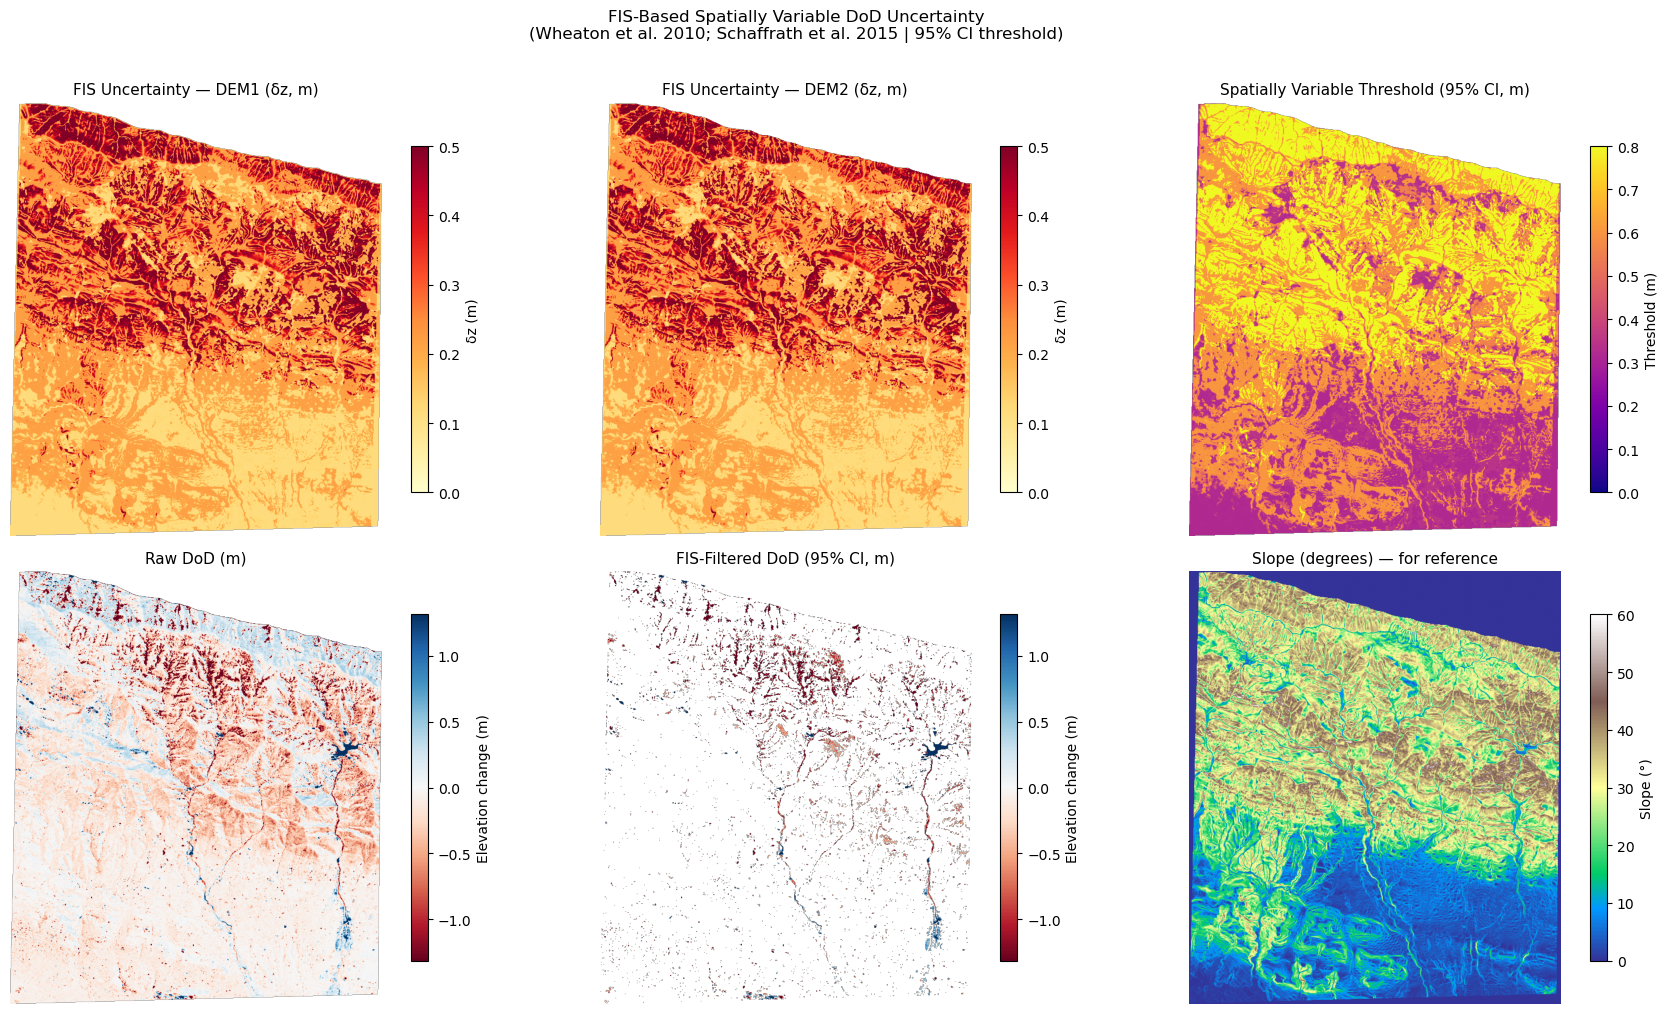


Plot saved: dod_fis_results.png

Done.


In [9]:
# =============================================================================
# 7. PLOT — Uncertainty Surface + Threshold + Filtered DoD
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Uncertainty DEM1
im0 = axes[0,0].imshow(uncertainty1, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0,0].set_title("FIS Uncertainty — DEM1 (δz, m)", fontsize=11)
axes[0,0].axis("off")
plt.colorbar(im0, ax=axes[0,0], label="δz (m)", shrink=0.8)

# Uncertainty DEM2
im1 = axes[0,1].imshow(uncertainty2, cmap="YlOrRd", vmin=0, vmax=0.5)
axes[0,1].set_title("FIS Uncertainty — DEM2 (δz, m)", fontsize=11)
axes[0,1].axis("off")
plt.colorbar(im1, ax=axes[0,1], label="δz (m)", shrink=0.8)

# Threshold surface
im2 = axes[0,2].imshow(threshold_surface, cmap="plasma", vmin=0, vmax=0.8)
axes[0,2].set_title("Spatially Variable Threshold (95% CI, m)", fontsize=11)
axes[0,2].axis("off")
plt.colorbar(im2, ax=axes[0,2], label="Threshold (m)", shrink=0.8)

# Raw DoD
vmax = np.nanpercentile(np.abs(dod_raw), 98)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im3 = axes[1,0].imshow(dod_raw, cmap="RdBu", norm=norm)
axes[1,0].set_title("Raw DoD (m)", fontsize=11)
axes[1,0].axis("off")
plt.colorbar(im3, ax=axes[1,0], label="Elevation change (m)", shrink=0.8)

# Filtered DoD
im4 = axes[1,1].imshow(dod_filtered, cmap="RdBu", norm=norm)
axes[1,1].set_title("FIS-Filtered DoD (95% CI, m)", fontsize=11)
axes[1,1].axis("off")
plt.colorbar(im4, ax=axes[1,1], label="Elevation change (m)", shrink=0.8)

# Slope (for reference)
im5 = axes[1,2].imshow(slope1, cmap="terrain", vmin=0, vmax=60)
axes[1,2].set_title("Slope (degrees) — for reference", fontsize=11)
axes[1,2].axis("off")
plt.colorbar(im5, ax=axes[1,2], label="Slope (°)", shrink=0.8)

plt.suptitle(
    "FIS-Based Spatially Variable DoD Uncertainty\n"
    "(Wheaton et al. 2010; Schaffrath et al. 2015 | 95% CI threshold)",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("dod_fis_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved: dod_fis_results.png")
print("\nDone.")


--- Statistical Summary of Filtered DoD ---
  Total valid pixels:   31,504
  Erosion pixels:       26,904  (85.4%)
  Deposition pixels:    4,600  (14.6%)
  Mean change:          -0.6938 m
  Std deviation:        2.5430 m
  Median change:        -0.7710 m
  Min (max erosion):    -15.0799 m
  Max (max deposition): 31.1996 m
  Skewness:             4.9131
  Kurtosis:             42.7708


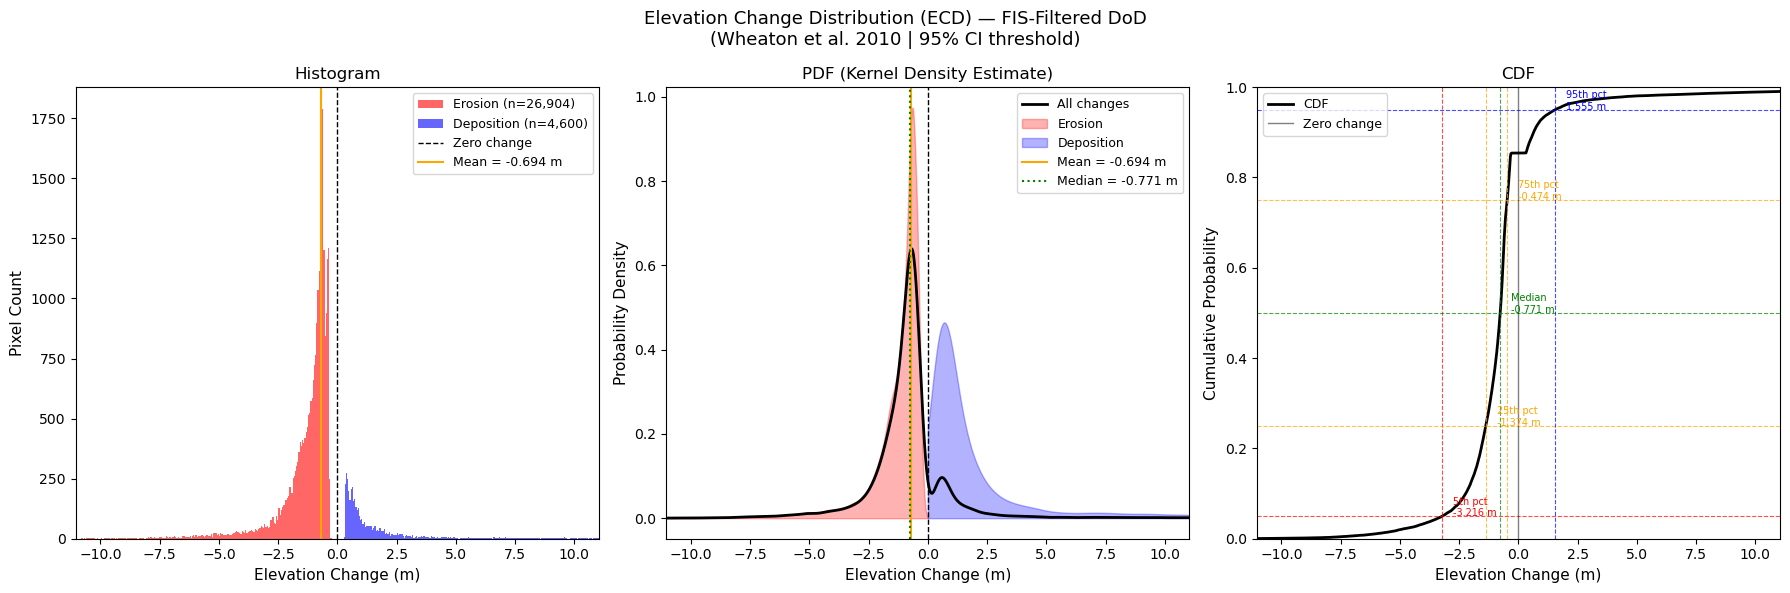

ECD analysis plot saved: dod_fis_ecd_analysis.png

Done.


In [10]:
# =============================================================================
# 8. STATISTICAL ANALYSIS — Histogram, PDF, and CDF of Filtered DoD
# =============================================================================
#
# What each plot shows:
#   Histogram  — raw count of pixels at each elevation change value
#   PDF        — probability density: how likely each change magnitude is
#                (area under curve = 1.0)
#   CDF        — cumulative probability: what fraction of pixels have
#                change ≤ x (goes from 0 to 1 left to right)
#
# These are standard Elevation Change Distribution (ECD) diagnostics
# used in Wheaton et al. (2010) Figures 9 and 11.
# =============================================================================
 
from scipy import stats
from scipy.stats import gaussian_kde
 
# Extract valid (non-NaN) filtered DoD values
dod_vals = dod_filtered[~np.isnan(dod_filtered)].flatten()
 
# Separate erosion (negative) and deposition (positive)
erosion    = dod_vals[dod_vals < 0]
deposition = dod_vals[dod_vals > 0]
 
# Clip extreme outliers for display (keep 99th percentile range)
clip_val = np.percentile(np.abs(dod_vals), 99)
x_range  = np.linspace(-clip_val, clip_val, 1000)
 
print("\n--- Statistical Summary of Filtered DoD ---")
print(f"  Total valid pixels:   {len(dod_vals):,}")
print(f"  Erosion pixels:       {len(erosion):,}  "
      f"({100*len(erosion)/len(dod_vals):.1f}%)")
print(f"  Deposition pixels:    {len(deposition):,}  "
      f"({100*len(deposition)/len(dod_vals):.1f}%)")
print(f"  Mean change:          {dod_vals.mean():.4f} m")
print(f"  Std deviation:        {dod_vals.std():.4f} m")
print(f"  Median change:        {np.median(dod_vals):.4f} m")
print(f"  Min (max erosion):    {dod_vals.min():.4f} m")
print(f"  Max (max deposition): {dod_vals.max():.4f} m")
print(f"  Skewness:             {stats.skew(dod_vals):.4f}")
print(f"  Kurtosis:             {stats.kurtosis(dod_vals):.4f}")
 
 
# --- Build figure: 3 panels side by side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    "Elevation Change Distribution (ECD) — FIS-Filtered DoD\n"
    "(Wheaton et al. 2010 | 95% CI threshold)",
    fontsize=13
)
 
# ── Panel 1: Histogram ──────────────────────────────────────────────────────
ax = axes[0]
bin_width = 0.05  # 5 cm bins — adjust for your data range
bins = np.arange(-clip_val, clip_val + bin_width, bin_width)
 
# Plot erosion (negative) in red, deposition (positive) in blue
ax.hist(erosion,    bins=bins, color="red",  alpha=0.6,
        label=f"Erosion (n={len(erosion):,})")
ax.hist(deposition, bins=bins, color="blue", alpha=0.6,
        label=f"Deposition (n={len(deposition):,})")
ax.axvline(0, color="black", linewidth=1.0, linestyle="--", label="Zero change")
ax.axvline(dod_vals.mean(), color="orange", linewidth=1.5,
           linestyle="-", label=f"Mean = {dod_vals.mean():.3f} m")
 
ax.set_xlabel("Elevation Change (m)", fontsize=11)
ax.set_ylabel("Pixel Count", fontsize=11)
ax.set_title("Histogram", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-clip_val, clip_val)
 
 
# ── Panel 2: PDF (Probability Density Function) ──────────────────────────────
# Uses kernel density estimation (KDE) — a smoothed version of the histogram
# where the total area under the curve = 1.0
ax = axes[1]
 
kde_all        = gaussian_kde(dod_vals,  bw_method=0.1)
kde_erosion    = gaussian_kde(erosion,   bw_method=0.1)
kde_deposition = gaussian_kde(deposition,bw_method=0.1)
 
x_neg = np.linspace(-clip_val, 0,        500)
x_pos = np.linspace(0,          clip_val, 500)
 
ax.plot(x_range, kde_all(x_range),
        color="black",  linewidth=2.0, label="All changes")
ax.fill_between(x_neg, kde_erosion(x_neg),
                color="red",  alpha=0.3, label="Erosion")
ax.fill_between(x_pos, kde_deposition(x_pos),
                color="blue", alpha=0.3, label="Deposition")
ax.axvline(0, color="black",  linewidth=1.0, linestyle="--")
ax.axvline(dod_vals.mean(), color="orange", linewidth=1.5,
           linestyle="-", label=f"Mean = {dod_vals.mean():.3f} m")
ax.axvline(np.median(dod_vals), color="green", linewidth=1.5,
           linestyle=":", label=f"Median = {np.median(dod_vals):.3f} m")
 
ax.set_xlabel("Elevation Change (m)", fontsize=11)
ax.set_ylabel("Probability Density", fontsize=11)
ax.set_title("PDF (Kernel Density Estimate)", fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(-clip_val, clip_val)
 
 
# ── Panel 3: CDF (Cumulative Distribution Function) ──────────────────────────
# Shows the fraction of pixels with elevation change ≤ x value
# Key reference points:
#   CDF = 0.50 → median (50% of pixels have change below this value)
#   CDF = 0.05 → 5th percentile (mostly erosion tail)
#   CDF = 0.95 → 95th percentile (mostly deposition tail)
ax = axes[2]
 
sorted_vals = np.sort(dod_vals)
cdf         = np.arange(1, len(sorted_vals) + 1) / len(sorted_vals)
 
ax.plot(sorted_vals, cdf, color="black", linewidth=2.0, label="CDF")
 
# Reference lines at key percentiles
for pct, color, label in [
    (0.05, "red",    "5th pct"),
    (0.25, "orange", "25th pct"),
    (0.50, "green",  "Median"),
    (0.75, "orange", "75th pct"),
    (0.95, "blue",   "95th pct"),
]:
    val = np.percentile(dod_vals, pct * 100)
    ax.axhline(pct, color=color, linewidth=0.8, linestyle="--", alpha=0.7)
    ax.axvline(val, color=color, linewidth=0.8, linestyle="--", alpha=0.7)
    ax.annotate(f"{label}\n{val:.3f} m",
                xy=(val, pct),
                xytext=(8, 0), textcoords="offset points",
                fontsize=7, color=color)
 
ax.axvline(0, color="black", linewidth=1.0, linestyle="-", alpha=0.5,
           label="Zero change")
ax.set_xlabel("Elevation Change (m)", fontsize=11)
ax.set_ylabel("Cumulative Probability", fontsize=11)
ax.set_title("CDF", fontsize=12)
ax.set_xlim(-clip_val, clip_val)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.savefig("dod_fis_ecd_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("ECD analysis plot saved: dod_fis_ecd_analysis.png")
print("\nDone.")